# Sesión 2 · Variables categóricas y numéricas
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 21 de agosto de 2026 |
| **Objetivo** | Analizar las variables categóricas y numéricas de House Prices: distribución, cardinalidad, tendencia central, skewness, outliers y correlación con el target. |

---

> Usamos el mismo `train.csv` que descargaron en la sesión 1. Si no lo tienen, revisen las instrucciones de descarga en el notebook de la sesión anterior o del `README.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')
print('Dataset cargado:', df.shape)

Dataset cargado: (1460, 81)


---
## PARTE 1

### 1.1 Categóricas · `value_counts()`

Antes de ver si una variable categórica se relaciona con el target, hay que saber cómo está distribuida ¿está balanceada o hay categorías dominantes?

In [2]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

### 1.2 Relación con el target. `groupby()` + `.mean()`

¿Cambia el precio promedio según el vecindario?

In [3]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(0)

Neighborhood
NoRidge    335295.0
NridgHt    316271.0
StoneBr    310499.0
Timber     242247.0
Veenker    238773.0
Somerst    225380.0
ClearCr    212565.0
Crawfor    210625.0
CollgCr    197966.0
Blmngtn    194871.0
Gilbert    192855.0
NWAmes     189050.0
SawyerW    186556.0
Mitchel    156270.0
NAmes      145847.0
NPkVill    142694.0
SWISU      142591.0
Blueste    137500.0
Sawyer     136793.0
OldTown    128225.0
Edwards    128220.0
BrkSide    124834.0
BrDale     104494.0
IDOTRR     100124.0
MeadowV     98576.0
Name: SalePrice, dtype: float64

Las diferencias entre vecindarios son de decenas de miles de dólares. `Neighborhood` sí parece tener relación con `SalePrice`. Vale la pena verlo también con un boxplot para ver la distribución completa, no solo el promedio.

### 1.3 Boxplot por categoría

El boxplot muestra la distribución completa del target dentro de cada grupo: mediana, dispersión y outliers, no solo el promedio.

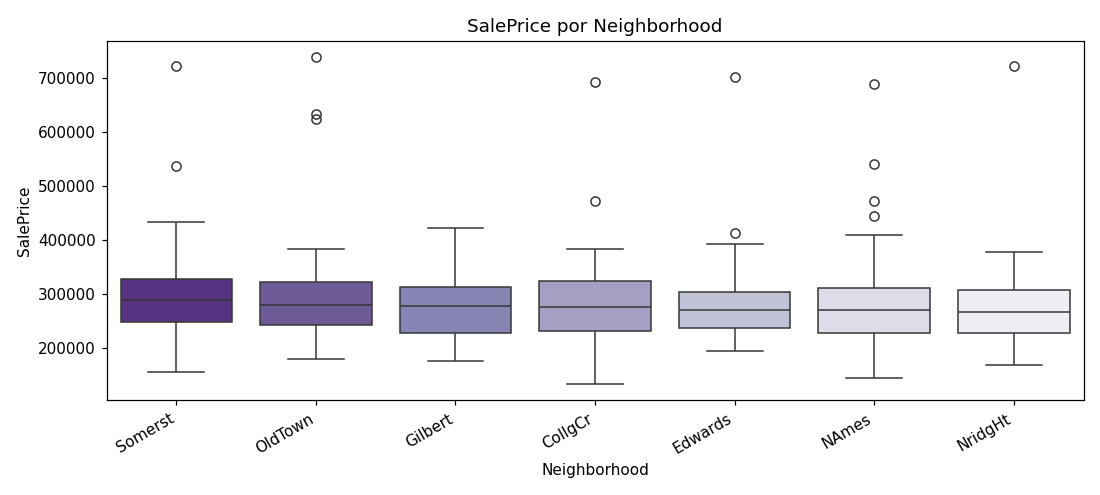

In [4]:
top_barrios = df.groupby('Neighborhood')['SalePrice'].median().nlargest(7).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df['Neighborhood'].isin(top_barrios)],
            x='Neighborhood', y='SalePrice', order=top_barrios, ax=ax)
ax.set_title('SalePrice por Neighborhood')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Las medianas entre vecindarios son parecidas (~$265k–$290k) y los IQR se solapan bastante. `Neighborhood` por sí solo no separa limpiamente casas caras de baratas. Todos los vecindarios tienen outliers solo hacia arriba, nunca hacia abajo, primera señal del sesgo positivo de `SalePrice` también dentro de cada grupo, no solo en la distribución global. `OldTown` destaca con 3 outliers marcados (~$620k–$740k), más que el resto, candidata a revisar de cerca.

### 1.4 Tendencia central y dispersión

In [4]:
print(f"Media:   {df['SalePrice'].mean():,.0f}")
print(f"Mediana: {df['SalePrice'].median():,.0f}")
print(f"Std:     {df['SalePrice'].std():,.0f}")
print(f"Rango:   {df['SalePrice'].min():,.0f} - {df['SalePrice'].max():,.0f}")

Media:   180,921
Mediana: 163,000
Std:     79,443
Rango:   34,900 - 755,000


La media ($180,921) es mayor que la mediana ($163,000). Segunda señal de sesgo positivo.

### 1.5 Skewness

In [5]:
print(f"SalePrice skew: {df['SalePrice'].skew():.2f}")
print(f"GrLivArea skew: {df['GrLivArea'].skew():.2f}")

SalePrice skew: 1.88
GrLivArea skew: 1.37


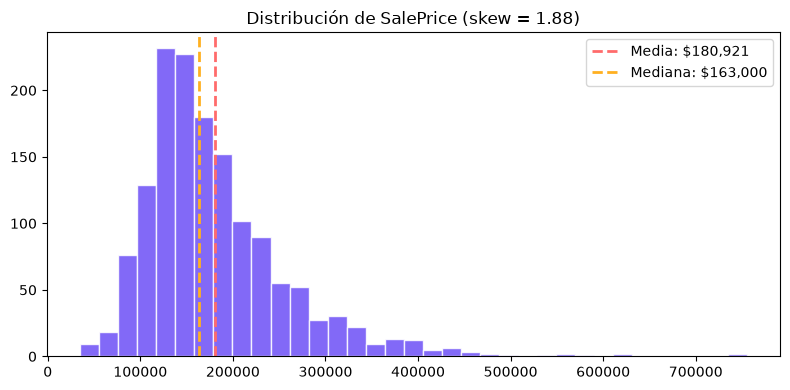

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['SalePrice'], bins=35, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2, linestyle='--',
           label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2, linestyle='--',
           label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax.set_title(f"Distribución de SalePrice (skew = {df['SalePrice'].skew():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

`SalePrice` tiene skew = 1.88 (|γ| > 1). Un sesgo positivo fuerte. `GrLivArea` en cambio tiene skew = 1.37, algo más simétrico.

### 1.6 Outliers · Regla de Tukey (1.5 × IQR)

In [7]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['GrLivArea'] < lim_inf) | (df['GrLivArea'] > lim_sup)]

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Límites: [{lim_inf:.0f}, {lim_sup:.0f}]')
print(f'Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Q1=1130  Q3=1777  IQR=647
Límites: [159, 2748]
Outliers encontrados: 31 (2.1%)


> Aplicamos Tukey sobre `GrLivArea` (skew bajo) y no sobre `SalePrice` directamente, con su sesgo de 1.88, la regla generaría muchos falsos positivos en la cola derecha. Eso se corrige transformando primero.

### 1.7 Correlación con el target

In [8]:
num_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'LotFrontage']
corr = df[num_cols].corr()

print(corr['SalePrice'].sort_values(ascending=False).round(2))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
YearBuilt      0.52
LotFrontage    0.35
Name: SalePrice, dtype: float64


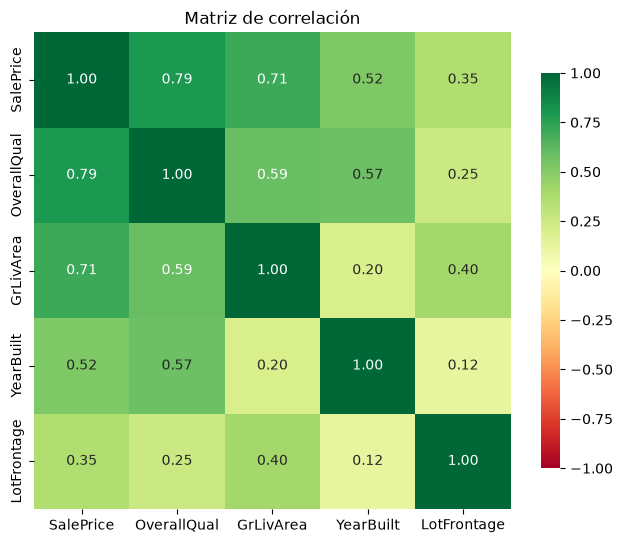

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

`GrLivArea` (0.79) y `OverallQual` (0.71) son las más correlacionadas con `SalePrice` en esta muestra. `LotFrontage` prácticamente no tiene relación lineal (0.35), es candidata a descartar sin mucho análisis adicional según la estrategia de priorización que vimos en la presentación.

---
## PARTE 2 

*A partir de aquí trabajan solos (en equipo). Completen las celdas de código y respondan en las celdas de interpretación.*

**Entregable:** este notebook, con todas las celdas ejecutadas y las interpretaciones completadas.

> Documentación oficial de pandas: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html).

### 2.1 Tabla de contingencia · `pd.crosstab()`

`pd.crosstab()` no se explicó en detalle en la presentación, búsquenla en la documentación de pandas antes de usarla.

Primero, creamos una categoría de precio a partir de `SalePrice` (ya que `crosstab` funciona mejor entre dos variables categóricas):

In [ ]:
# Creamos una categoría binaria a partir de la mediana
mediana = df['SalePrice'].median()
df['CategoriaPrecio'] = np.where(df['SalePrice'] >= mediana, 'Caro', 'Económico')

df[['SalePrice', 'CategoriaPrecio']].head()

In [ ]:
# Posteriormente se crea una tabla de contingencia entre CentralAir y CategoriaPrecio


In [ ]:
# Con normalize='index' obtenemos proporciones por fila en vez de conteos


**Interpretación:**

*¿Las casas con aire acondicionado central (`CentralAir = 'Y'`) tienden más a estar en la categoría 'Caro'? ¿Qué proporción de las casas sin aire acondicionado caen en cada categoría?*

*(escriban su respuesta aquí)*

### 2.2 Cardinalidad de todas las variables categóricas

Revisen la cardinalidad de **todas** las columnas categóricas del dataset, no solo `Neighborhood`.

**Interpretación:**

*¿Alguna columna tiene cardinalidad sospechosamente alta (cercana al número de filas)? ¿Qué columna del dataset es? ¿Qué se debería de hacer con esta?*

*(escriban su respuesta aquí)*

### 2.3 Boxplot de dos variables categóricas adicionales

Elijan **dos** variables categóricas del dataset (distintas a `Neighborhood`) y grafiquen su boxplot contra `SalePrice`.

In [ ]:
# Variable categórica 1

In [ ]:
# Variable categórica 2

**Interpretación:**

*Para cada una de las dos variables que eligieron: ¿parece haber una relación clara con SalePrice, o las distribuciones se ven muy parecidas entre categorías?*

*(escriban su respuesta aquí)*

### 2.4 Skewness de todas las variables numéricas

Calculen el skewness de todas las columnas numéricas a la vez (no solo `SalePrice` y `GrLivArea`) y ordénenlas de mayor a menor sesgo.

**Interpretación:**

*¿Qué variables tienen |skew| > 1? ¿Alguna las sorprendió?*

*(escriban su respuesta aquí)*

### 2.5 Matriz de correlación completa

En la demo solo usamos 5 columnas numéricas. Ahora calculen la matriz de correlación con **todas** las columnas numéricas del dataset.

**Interpretación:**

*¿Cuáles son las 3 variables más correlacionadas con SalePrice en el dataset completo? Según la estrategia de priorización de la presentación, ¿en qué variables se enfocarían primero si tuvieran que elegir solo 5 para seguir explorando?*

*(escriban su respuesta aquí)*

---
## Resumen de hallazgos (conclusión del equipo)

| Pregunta | Respuesta del equipo |
|---|---|
| ¿`Neighborhood` parece influir en `SalePrice`? | |
| ¿Cuál es la columna categórica con mayor cardinalidad (aparte de un ID)? | |
| ¿`SalePrice` tiene sesgo? ¿Positivo o negativo, y qué tan fuerte? | |
| ¿Qué porcentaje de outliers encontraron en `GrLivArea`? | |
| ¿Cuáles son las 3 variables más correlacionadas con el target? | |
| ¿Qué variable descartarían de entrada por baja correlación y baja variabilidad? | |